In [71]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pickle as pkl
import arviz as az
import json

In [72]:
#df_Nfd = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/total_mzcounts_sorted.csv')
df_new = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/new_data_MZB.csv')
df_ont = pd.read_excel('/home/apoorva/Desktop/work/MZ_analysis/data/20190412_MV_Bcellnumbers_ontogeny.xlsx', sheet_name='SPLEEN_Cell number')



file_path = '/home/apoorva/Desktop/work/MZ_analysis/data/new_mzontogeny.varyinflux.TDMT2.pkl'
if os.path.getsize(file_path) > 0:
    with open(file_path, 'rb') as f:
        data_neutral = pkl.load(f)
else:
    raise EOFError("File is empty")
print(df_new.head(10))
print(df_ont.head(10))

                               Unnamed: 0  Age at BMT  Age at S1K  \
0  20181129_Bcells_SPLEEN_14d_001_019.fcs          74          88   
1  20181129_Bcells_SPLEEN_14d_002_020.fcs          41          88   
2      20181204_2-5wks_SPLEEN_001_018.fcs          74          92   
3      20181204_2-5wks_SPLEEN_002_019.fcs          41          59   
4        20181207_3wks_SPLEEN_001_048.fcs          74          95   
5        20181207_3wks_SPLEEN_002_049.fcs          41          62   
6        20181213_4wks_SPLEEN_001_024.fcs          74         102   
7        20181213_4wks_SPLEEN_002_025.fcs          41          69   
8   20181220_5wks_SPLEEN_CD1d_001_065.fcs          74         109   
9   20181220_5wks_SPLEEN_CD1d_002_066.fcs          41          76   

   Days postBMT  Lamis ID      total_FM     fd_FM  frac_Ki67+_FM_donor  \
0            14    832634  2.247009e+07  0.016125             0.441377   
1            14    848687  2.440681e+07  0.013667             0.485563   
2            18   

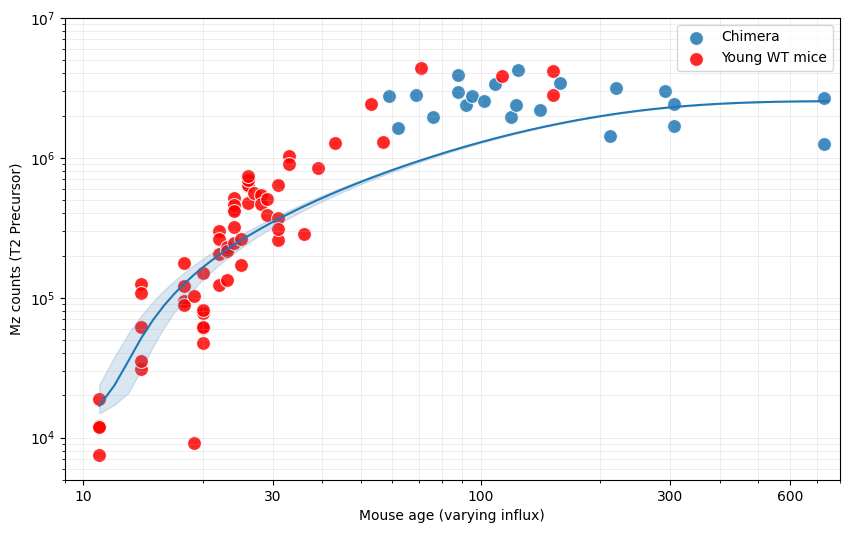

In [73]:
ts2= np.arange(11, 750, 1)
# ts1= np.arange(11, 152, 1)
# ts2 = np.arange(11, 190, 1)

# Plot the Mz counts
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=100, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ', alpha=0.85, s=100, color= 'Red',label='Young WT mice', legend=False)
plt.plot(ts2, np.mean(data_neutral.MZ_counts_pred, axis=0))
plt.fill_between(ts2, np.percentile(data_neutral.MZ_counts_pred, 2.5, axis=0), np.percentile(data_neutral.MZ_counts_pred, 97.5, axis=0), alpha=0.2, color='steelblue')
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(9, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 100, 300, 600], [10, 30, 100, 300, 600])
plt.xlabel('Mouse age (varying influx)')
plt.ylabel('Mz counts (T2 Precursor)')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()



In [74]:
# Print mean values of the parameters

# print(np.mean(data_neutral.r_phi))
# print(np.mean(data_neutral.t0))
# print(np.mean(data_neutral.alpha))

array([<Axes: title={'center': 'r_phi'}>, <Axes: title={'center': 't0'}>],
      dtype=object)

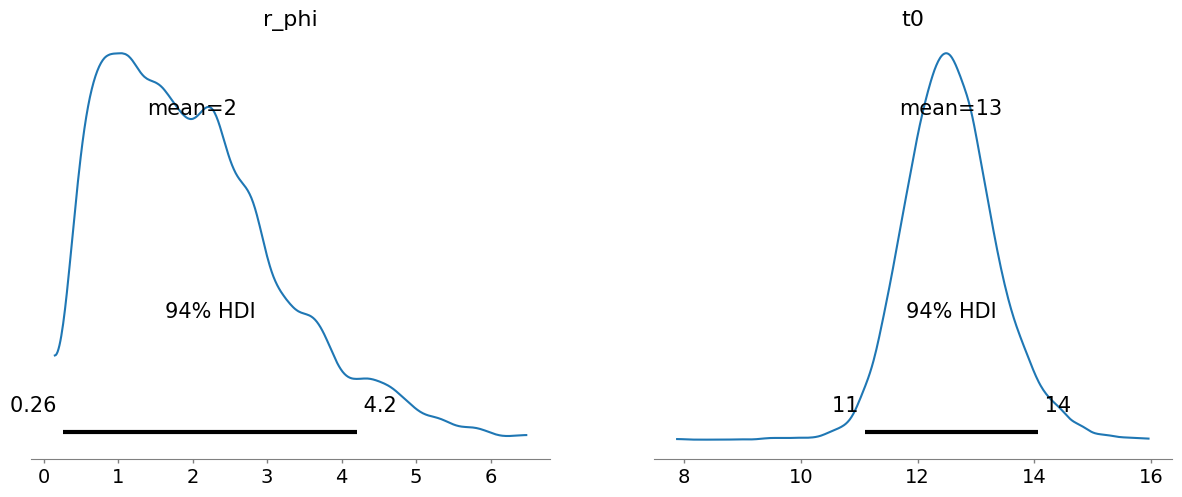

In [75]:
# Posterior distribution of parameters

# az.plot_posterior(data_neutral, var_names=['phi', 'r_phi','lambda'], kind='kde')
az.plot_posterior(data_neutral, var_names=[ 'r_phi','t0'], kind='kde')



/tmp/ipykernel_3473545/502062359.py:9: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  axes.set_xlim(0, 750)


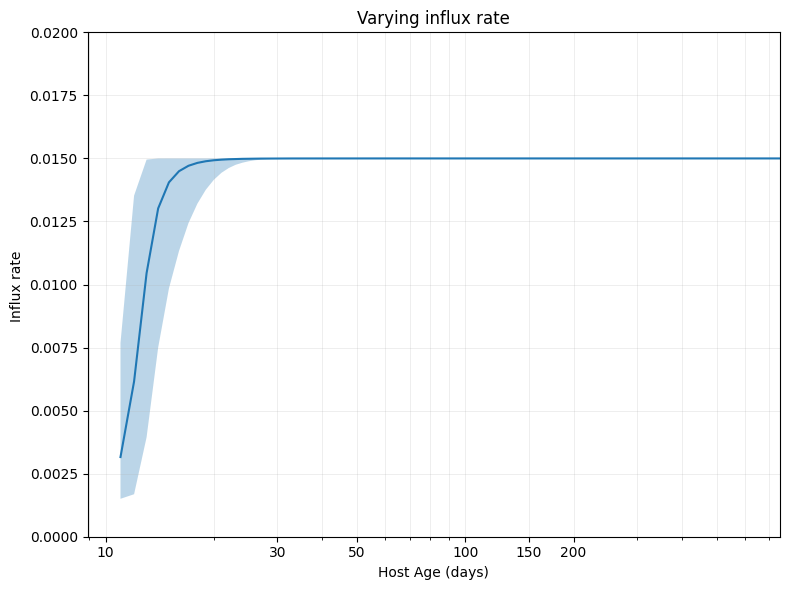

In [76]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(ts2, np.mean(data_neutral.influx_rate, axis=0))
axes.fill_between(ts2, np.quantile(data_neutral.influx_rate, 0.025, axis=0), np.quantile(data_neutral.influx_rate, 0.975, axis=0), alpha=0.3)
axes.set_ylim(0, 0.02)
# axes.set_yscale('log')
# axes.set_yticks([0, 0.005, 0.01, 0.015, 0.02])
# axes.set_yticklabels([0, 0.005, 0.01, 0.015, 0.02])
axes.set_xscale('log')
axes.set_xlim(0, 750)
axes.set_xticks([10, 30, 50, 100, 150, 200])
axes.set_xticklabels([10, 30,  50, 100, 150, 200])
axes.set_ylabel('Influx rate ')
axes.set_xlabel('Host Age (days)')
axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
axes.set_title('Varying influx rate')
plt.tight_layout()
plt.show()

In [77]:
# Rate of influx of T1 into MZ

# def phi(t, r_phi):
    # phi = 0.014
    # phi_var = phi / (1 + np.exp(-r_phi * (t-20)))
    # return phi_var
# def phi(t, r_phi):
#     if(t < 40):
#      r_phi = 0.017
#      phi = 0.014
#      phi_var =  phi * (1 - np.exp(-(r_phi) * (t-10)**1.8))
#     else:
#       phi_var = 0.014
#     return(phi_var)

def phi(t, r_phi, alpha, t0):
    phi_value = 0.014  # Assuming phi is a constant value
    phi_var =  ((phi_value - alpha) / (1 + np.exp(-(r_phi) * (t- t0)))) + alpha
    return phi_var

def P(t):

    theta_0 = np.exp(14.17)
    nu = 0.31
    n = 1.98
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))

t = np.arange(11, 152, 1)

# influx_p = np.zeros((8000, 739))
# for i in range(0, 739):  # Ensure the loop does not exceed the bounds
#     # influx_p[:, i] = (phi(i + 11, data_neutral.r_phi, data_neutral.alpha) * P(i + 11)) / data_neutral.MZ_counts_pred[:, i]
#     influx_p[:, i] = (phi(i + 11, data_neutral.r_phi) * P(i + 11)) / data_neutral.MZ_counts_pred[:, i]
    

influx_rate = np.zeros((8000, 739))
for i in range(0, 739):  # Ensure the loop does not exceed the bounds
    influx_rate[:, i] = phi(i + 11, data_neutral.r_phi, data_neutral.alpha, data_neutral.t0) 
 


# # influx = np.array(influx)
# print(len(influx_p))
# print(influx_p.shape)
# # print(np.quantile(influx_p, 0.025, axis=0))
# # print(np.quantile(influx_p, 0.975, axis=0))

# # Plot precursor influx with 95% CI

# fig, axes = plt.subplots(1, 1, figsize=(8, 6))
# axes.plot(ts1, np.mean(influx_p, axis=0))
# axes.fill_between(ts1, np.quantile(influx_p, 0.025, axis=0), np.quantile(influx_p, 0.975, axis=0), alpha=0.3)
# axes.set_ylim(0, 0.15)
# # axes.set_yticks([0, 0.005, 0.01, 0.015, 0.02])
# # axes.set_yticklabels([0, 0.005, 0.01, 0.015, 0.02])
# axes.set_xlim(10, 750)
# axes.set_xticks([50, 200, 350, 500])
# axes.set_xticklabels([50, 200, 350, 500])
# axes.set_ylabel('Fraction of influx')
# axes.set_xlabel('Host Age (days)')
# axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
# axes.set_title('Proportion of influx of TA44.1 precursor cells into the MZ pool')
# plt.tight_layout()
# plt.show()


AttributeError: Unknown variable name: alpha
Available variables are sigma, r_phi, t0, y1, k_hat, totalMz_mean, MZ_counts_mean, parms, k_hat_pred1, MZ_counts_pred, influx_rate, log_lik_Mz, residuals_Mz

ValueError: x and y must have same first dimension, but have shapes (141,) and (739,)

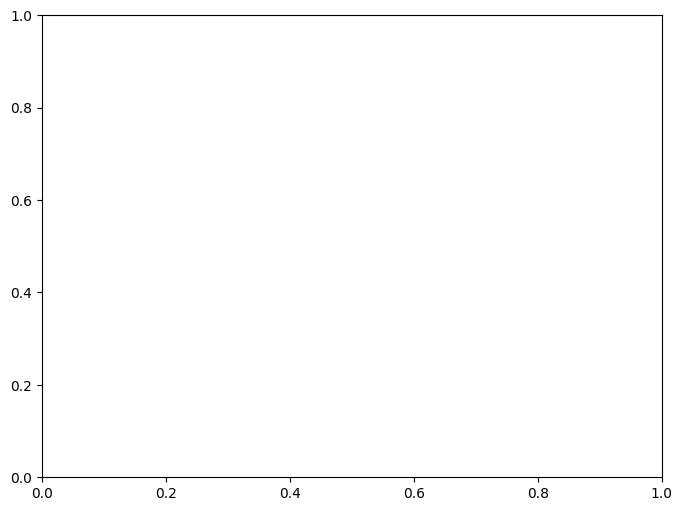

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
ts1= np.arange(11, 152, 1)
axes.plot(ts1, np.mean(influx_rate, axis=0))
axes.fill_between(ts1, np.quantile(influx_rate, 0.025, axis=0), np.quantile(influx_rate, 0.975, axis=0), alpha=0.3)
axes.set_ylim(0, 0.02)
axes.set_xscale('log')
# axes.set_yticks([0, 0.005, 0.01, 0.015, 0.02])
# axes.set_yticklabels([0, 0.005, 0.01, 0.015, 0.02])
axes.set_xlim(0, 800)
axes.set_xticks([ 11, 40, 200, 400, 600])
axes.set_xticklabels([ 11, 40, 200, 400, 600])
axes.set_ylabel('Fraction of influx')
axes.set_xlabel('Host Age (days)')
axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
axes.set_title('Varying influx rate')
plt.tight_layout()
plt.show()